In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sns


In [2]:
dta = pd.read_csv('Advertising.csv')
dta = dta.drop(columns=['ID'])
r = dta[['TV', 'Radio', 'Newspaper']]
s = dta['Sales']

In [3]:
from sklearn.model_selection import train_test_split
r_train,r_test,s_train,s_test=train_test_split(r,s,test_size=0.1,random_state=40)

In [4]:
dta.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
sales_predictor=LinearRegression()

In [7]:
sales_predictor.fit(r_train,s_train)

LinearRegression()

In [8]:
s_train_predictor = sales_predictor.predict(r_train)


In [9]:
from math import sqrt

In [10]:
from sklearn.metrics import mean_squared_error,r2_score

In [11]:
sqrt(mean_squared_error(s_train,s_train_predictor))

1.6444076830054912

In [12]:
r2_score(s_train,s_train_predictor)

0.9018980130583387

In [13]:
s_test_predictor=sales_predictor.predict(r_test)

In [14]:
sqrt(mean_squared_error(s_test,s_test_predictor))

1.8876764745672008

In [15]:
r2_score(s_test,s_test_predictor)

0.84353876554193

In [16]:
def sales(TV, Radio, Newspaper):
    return sales_predictor.predict([[TV, Radio, Newspaper]])

In [17]:
tv= float(input('Enter TV advertising budget: '))
radio = float(input('Enter Radio advertising budget: '))
newspaper= float(input('Enter Newspaper advertising budget: '))
prediction = sales(tv, radio, newspaper)
print("\nPredicted Sales:", prediction[0])

Enter TV advertising budget:  9875
Enter Radio advertising budget:  547
Enter Newspaper advertising budget:  54



Predicted Sales: 553.1223556667632


C:\Users\AdminIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


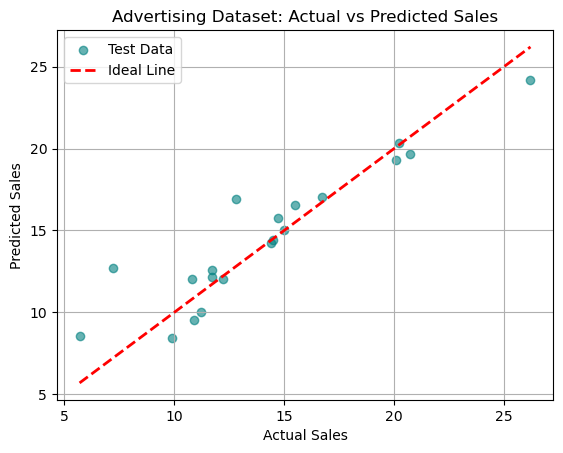

In [18]:
plt.scatter(s_test, s_test_predictor, color='teal', alpha=0.6, label='Test Data')
plt.plot([s_test.min(), s_test.max()], [s_test.min(), s_test.max()], color='red', linestyle='--', linewidth=2, label='Ideal Line')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Advertising Dataset: Actual vs Predicted Sales')
plt.legend()
plt.grid()
plt.show()
def predict_new_sales(tv, radio, newspaper):
    prediction = sales_predictor.predict([[tv, radio, newspaper]])